In [1]:
# Import tools
import json
import shutil
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from google.colab import files
from IPython.display import display
from itertools import product
from pathlib import Path
from scipy.linalg import qr
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from scipy.stats import beta as beta_distribution
from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics.pairwise import haversine_distances
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


In [2]:
# Set plot style
plt.rc("text",usetex=False)
plt.rc("font",family="serif")
plt.rc("mathtext",fontset="cm")
plt.rc("font",size=13)
plt.rc("axes",labelsize=14)
plt.rc("xtick",labelsize=11)
plt.rc("ytick",labelsize=11)
plt.rc("legend",fontsize=11)
plt.rc("xtick",top=False,direction="out")
plt.rc("ytick",right=False,direction="out")
plt.rc("xtick.major",size=4.5,width=0.9)
plt.rc("ytick.major",size=4.5,width=0.9)
plt.rc("lines",linewidth=1.8,markersize=4.5,markeredgewidth=0.8)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
colors = {"blue":"#0072B2","orange":"#D55E00","green":"#009E73","purple":"#CC79A7","gray":"#7F7F7F"}


In [3]:
# Load region data
archive = Path("regions.zip")
if not archive.exists():
    uploaded = files.upload()
    archives = [Path(name) for name in uploaded if Path(name).suffix.lower()==".zip"]
    if len(archives)!=1:
        raise ValueError("Upload exactly one regions.zip archive")
    archive = archives[0]
required = ["sites.csv","target.csv","pm.csv","smoke.csv"]
data = Path("regions_data")
shutil.rmtree(data,ignore_errors=True)
data.mkdir()
with zipfile.ZipFile(archive) as bundle:
    members = {Path(name).name:name for name in bundle.namelist()}
    missing = [name for name in required if name not in members]
    if missing:
        raise FileNotFoundError("Missing archive files: "+", ".join(missing))
    for name in required:
        with bundle.open(members[name]) as source, open(data/name,"wb") as output:
            shutil.copyfileobj(source,output)
sites = pd.read_csv(data/"sites.csv",dtype={"site":str})
target = pd.read_csv(data/"target.csv",dtype={"site":str})
pm = pd.read_csv(data/"pm.csv",index_col=0)
smoke = pd.read_csv(data/"smoke.csv",index_col=0)
pm.index = pd.to_datetime(pm.index)
smoke.index = pd.to_datetime(smoke.index)
pm.columns = pm.columns.astype(str)
smoke.columns = smoke.columns.astype(str)
pm = pm.apply(pd.to_numeric,errors="coerce").sort_index()
smoke = smoke.apply(pd.to_numeric,errors="coerce").sort_index()
target["weight"] = pd.to_numeric(target["weight"],errors="coerce")
order = target["site"].tolist()
sites = sites.set_index("site").reindex(order).reset_index()
pm = pm.reindex(columns=order)
smoke = smoke.reindex(index=pm.index,columns=order).fillna(0).astype(int)
checks = {
    "104 stations":len(order)==104,
    "Unique station IDs":len(set(order))==len(order),
    "Site metadata complete":sites[["lat","lon"]].notna().all().all(),
    "Target weights sum to one":np.isclose(target["weight"].sum(),1,atol=1e-10),
    "Twenty-one target stations":target["weight"].gt(0).sum()==21,
    "Matrices aligned":list(pm.columns)==order and list(smoke.columns)==order and pm.shape==smoke.shape,
    "Dates ordered and unique":pm.index.is_monotonic_increasing and pm.index.is_unique,
    "June through October only":set(pm.index.month).issubset({6,7,8,9,10}),
    "Smoke levels valid":set(np.unique(smoke.to_numpy())).issubset({0,1,2,3})
}
inputchecks = pd.DataFrame({"check":checks.keys(),"passed":checks.values()})
display(inputchecks)
if not inputchecks["passed"].all():
    failed = inputchecks.loc[~inputchecks["passed"],"check"].tolist()
    raise ValueError("Failed input checks: "+", ".join(failed))
print("Archive:",archive)
print("PM matrix:",pm.shape)
print("Date range:",pm.index.min().date(),pm.index.max().date())
print("Missing fraction:",f"{pm.isna().mean().mean():.4f}")


Saving 01-regions.zip to 01-regions.zip


,check,passed
0,104 stations,True
1,Unique station IDs,True
2,Site metadata complete,True
3,Target weights sum to one,True
4,Twenty-one target stations,True
5,Matrices aligned,True
6,Dates ordered and unique,True
7,June through October only,True
8,Smoke levels valid,True


Archive: 01-regions.zip
PM matrix: (1071, 104)
Date range: 2018-06-01 2024-10-31
Missing fraction: 0.1624


In [4]:
# Define validation targets
weights = target.set_index("site")["weight"].reindex(order).fillna(0)
fullsites = weights[weights>0].index.tolist()
targetfractions = pm[fullsites].notna().groupby(pm.index.year).mean().T
commonsites = targetfractions.index[targetfractions.min(axis=1)>=.75].tolist()
fullweights = weights[fullsites]/weights[fullsites].sum()
commonretained = weights[commonsites].sum()
commonweights = weights[commonsites]/commonretained
def observed_target(matrix,siteweights,threshold):
    block = matrix[siteweights.index]
    coverage = block.notna().mul(siteweights,axis=1).sum(axis=1)
    value = block.mul(siteweights,axis=1).sum(axis=1)/coverage.where(coverage>0)
    return pd.DataFrame({"target":value.where(coverage>=threshold),"coverage":coverage})
full90 = observed_target(pm,fullweights,.90)
full85 = observed_target(pm,fullweights,.85)
common90 = observed_target(pm,commonweights,.90)
smokeshare = smoke.ge(1).mul(fullweights,axis=1).sum(axis=1)
mediumshare = smoke.ge(2).mul(fullweights,axis=1).sum(axis=1)
heavyshare = smoke.ge(3).mul(fullweights,axis=1).sum(axis=1)


In [5]:
# Build validation samples
available = set(pm.index)
rows = []
for targetdate in pm.index:
    inputdates = [targetdate-pd.Timedelta(days=4),targetdate-pd.Timedelta(days=3),targetdate-pd.Timedelta(days=2)]
    if not all(date in available for date in inputdates):
        continue
    if not all(date.year==targetdate.year for date in inputdates):
        continue
    block = pm.loc[inputdates]
    rows.append({
        "target_date":targetdate,
        "first_date":inputdates[0],
        "middle_date":inputdates[1],
        "latest_date":inputdates[2],
        "year":targetdate.year,
        "input_fraction":block.notna().mean().mean(),
        "complete_stations":int(block.notna().all(axis=0).sum()),
        "smoke_share":smokeshare.loc[targetdate],
        "medium_heavy_share":mediumshare.loc[targetdate],
        "heavy_share":heavyshare.loc[targetdate]
    })
samples = pd.DataFrame(rows)
samples["split"] = np.select(
    [samples["year"].between(2018,2021),samples["year"].eq(2022),samples["year"].between(2023,2024)],
    ["train","validation","test"],
    default="exclude"
)
for name,frame in [("full90",full90),("full85",full85),("common90",common90)]:
    samples[f"target_{name}"] = frame["target"].reindex(samples["target_date"]).to_numpy()
    samples[f"coverage_{name}"] = frame["coverage"].reindex(samples["target_date"]).to_numpy()
samples["smoke_any"] = samples["smoke_share"].gt(0)
samples["medium_heavy_any"] = samples["medium_heavy_share"].gt(0)
samples["heavy_any"] = samples["heavy_share"].gt(0)


In [6]:
# Qualify graph candidates
training = pm[pm.index.year<=2021]
yearcounts = training.notna().groupby(training.index.year).sum().T.reindex(columns=[2018,2019,2020,2021],fill_value=0)
trainingyears = yearcounts.gt(0).sum(axis=1)
mediandays = yearcounts.where(yearcounts>0).median(axis=1)
candidatepass = trainingyears.ge(3)&mediandays.ge(40)
candidateorder = yearcounts.index[candidatepass].tolist()
candidatesites = sites.set_index("site").reindex(candidateorder).reset_index()
candidateweights = weights.reindex(candidateorder).fillna(0)
stationaudit = pd.DataFrame({
    "site":yearcounts.index,
    "target_weight":weights.reindex(yearcounts.index).to_numpy(),
    "training_years":trainingyears.to_numpy(),
    "median_training_days":mediandays.to_numpy(),
    "passes_training_rule":candidatepass.to_numpy()
})


In [7]:
# Audit validation protocol
comparison = pd.concat([full90["target"].rename("full"),common90["target"].rename("common")],axis=1)
comparison = comparison.loc[comparison.index.year<=2022].dropna()
difference = comparison["common"]-comparison["full"]
targetagreement = pd.DataFrame([{
    "days":len(comparison),
    "correlation":comparison.corr().iloc[0,1],
    "mae":difference.abs().mean(),
    "rmse":np.sqrt(np.mean(difference**2)),
    "bias":difference.mean(),
    "normalized_mae":difference.abs().mean()/comparison["full"].std(),
    "normalized_rmse":np.sqrt(np.mean(difference**2))/comparison["full"].std()
}])
targetprotocols = pd.DataFrame({
    "protocol":["primary","robustness","sensitivity"],
    "target":["target_full90","target_common90","target_full85"],
    "years":["2024","2023-2024","2023-2024"],
    "stations":[21,17,21],
    "coverage":[.90,.90,.85]
})
protocols = {
    "primary_full90_2024":("target_full90",[2024]),
    "robust_common90_2023_2024":("target_common90",[2023,2024]),
    "sensitivity_full85_2023_2024":("target_full85",[2023,2024])
}
protocolsummary = pd.DataFrame([
    {
        "protocol":name,
        "years":",".join(map(str,years)),
        "samples":len(group),
        "target_mean":group[column].mean(),
        "target_sd":group[column].std(),
        "smoke_any":int(group["smoke_any"].sum()),
        "medium_heavy_any":int(group["medium_heavy_any"].sum()),
        "heavy_any":int(group["heavy_any"].sum())
    }
    for name,(column,years) in protocols.items()
    for group in [samples[samples["year"].isin(years)&samples[column].notna()]]
])
samplesummary = samples.groupby(["split","year"],as_index=False).agg(
    windows=("target_date","size"),
    full90=("target_full90",lambda x:x.notna().sum()),
    common90=("target_common90",lambda x:x.notna().sum()),
    median_complete_stations=("complete_stations","median"),
    median_input_fraction=("input_fraction","median")
)
checks = {
    "Input audit passes":inputchecks["passed"].all(),
    "Ninety-nine candidates":len(candidateorder)==99,
    "Target weight preserved":np.isclose(candidateweights.sum(),1),
    "Common support fixed":len(commonsites)==17,
    "Common support retains over eighty percent":commonretained>=.80,
    "Primary test has over one hundred samples":samples.loc[samples["year"].eq(2024),"target_full90"].notna().sum()>=100,
    "Robust test contains both years":all(samples.loc[samples["year"].eq(year),"target_common90"].notna().sum()>0 for year in [2023,2024])
}
protocolchecks = pd.DataFrame({"check":checks.keys(),"passed":checks.values()})
if not protocolchecks["passed"].all():
    failed = protocolchecks.loc[~protocolchecks["passed"],"check"].tolist()
    raise ValueError("Failed protocol checks: "+", ".join(failed))
display(samplesummary)
display(targetagreement)
display(protocolsummary)
display(protocolchecks)


,split,year,windows,full90,common90,median_complete_stations,median_input_fraction
0,test,2023,149,0,98,87.0,0.875000
1,test,2024,149,135,137,87.0,0.875000
2,train,2018,149,140,140,73.0,0.778846
3,train,2019,149,137,139,74.0,0.794872
4,train,2020,149,149,149,76.0,0.814103
5,train,2021,149,149,149,85.0,0.871795
6,validation,2022,149,147,147,84.0,0.858974


,days,correlation,mae,rmse,bias,normalized_mae,normalized_rmse
0,735,0.999588,0.191588,0.31218,0.100093,0.018836,0.030692


,protocol,years,samples,target_mean,target_sd,smoke_any,medium_heavy_any,heavy_any
0,primary_full90_2024,2024,135,6.883711,3.074779,51,11,1
1,robust_common90_2023_2024,"2023,2024",235,7.210782,4.646550,94,16,1
2,sensitivity_full85_2023_2024,"2023,2024",237,7.171950,4.629397,94,17,1


,check,passed
0,Input audit passes,True
1,Ninety-nine candidates,True
2,Target weight preserved,True
3,Common support fixed,True
4,Common support retains over eighty percent,True
5,Primary test has over one hundred samples,True
6,Robust test contains both years,True


In [8]:
# Build training graph
coordinates = np.radians(candidatesites[["lat","lon"]].to_numpy())
distance = 6371.0088*haversine_distances(coordinates)
n = len(candidateorder)
k = 10
neighbors = np.argsort(distance,axis=1)[:,1:k+1]
edgemask = np.zeros((n,n),dtype=bool)
edgemask[np.repeat(np.arange(n),k),neighbors.reshape(-1)] = True
edgemask = edgemask|edgemask.T
np.fill_diagonal(edgemask,False)
presence = training[candidateorder].notna().astype(np.int16)
overlap = (presence.T@presence).to_numpy()
correlation = training[candidateorder].corr(min_periods=60).fillna(0).to_numpy()
correlation = np.clip(correlation,-1,1)
np.fill_diagonal(correlation,1)
upper = np.triu(edgemask,1)
sigma = np.median(distance[upper])
W = np.where(edgemask,np.exp(-(distance/sigma)**2)*np.maximum(correlation,0)**2,0)
W = (W+W.T)/2
np.fill_diagonal(W,0)
components,_ = connected_components(csr_matrix(W>0),directed=False)
degree = W.sum(axis=1)
L = np.diag(degree)-W
values,vectors = np.linalg.eigh(L)
values = np.maximum(values,0)


In [9]:
# Audit training graph
graphsummary = pd.DataFrame({
    "metric":[
        "Candidate stations","Geographic edges","Positive weighted edges","Connected components",
        "Minimum weighted degree","Distance scale km","Median edge overlap","Algebraic connectivity"
    ],
    "value":[
        n,upper.sum(),np.triu(W>0,1).sum(),components,degree.min(),sigma,
        np.median(overlap[upper]),values[1]
    ]
})
checks = {
    "Training years only":training.index.year.max()==2021,
    "Weights finite":np.isfinite(W).all(),
    "Weights symmetric":np.allclose(W,W.T),
    "Weights nonnegative":W.min()>=0,
    "Zero diagonal":np.allclose(np.diag(W),0),
    "No isolated stations":np.all(degree>0),
    "Graph connected":components==1,
    "Single zero eigenvalue":values[1]>1e-10
}
graphchecks = pd.DataFrame({"check":checks.keys(),"passed":checks.values()})
if not graphchecks["passed"].all():
    failed = graphchecks.loc[~graphchecks["passed"],"check"].tolist()
    raise ValueError("Failed graph checks: "+", ".join(failed))
display(graphsummary)
display(graphchecks)


,metric,value
0,Candidate stations,99.000000
1,Geographic edges,634.000000
2,Positive weighted edges,634.000000
3,Connected components,1.000000
4,Minimum weighted degree,0.002572
5,Distance scale km,73.290595
6,Median edge overlap,558.000000
7,Algebraic connectivity,0.000859


,check,passed
0,Training years only,True
1,Weights finite,True
2,Weights symmetric,True
3,Weights nonnegative,True
4,Zero diagonal,True
5,No isolated stations,True
6,Graph connected,True
7,Single zero eigenvalue,True


In [10]:
# Define graph methods
def build_target_model(K,horizon,targetweights):
    scaled = values[:K]/values[K-1]
    basis = vectors[:,:K]
    decay = np.exp(-np.outer(horizon*np.array([0,.25,.5]),scaled))
    blocks = basis[:,None,:]*decay[None,:,:]
    g = np.exp(-horizon*scaled)*(basis.T@targetweights.reindex(candidateorder).fillna(0).to_numpy())
    info = np.einsum("vtk,vtl->vkl",blocks,blocks)
    return blocks,info,g
def select_taps(info,g,beta,budget):
    M = beta*np.eye(len(g))
    selected = []
    available = np.ones(len(info),dtype=bool)
    normalizer = g@g
    for step in range(budget):
        best = -1
        bestscore = np.inf
        for station in np.flatnonzero(available):
            solution = np.linalg.solve(M+info[station],g)
            score = beta*(g@solution)/normalizer
            if score<bestscore-1e-14:
                best = station
                bestscore = score
        selected.append(best)
        available[best] = False
        M = M+info[best]
    return selected
def graph_predictions(blocks,g,beta,selected,frame):
    K = blocks.shape[2]
    design = blocks[selected].reshape(-1,K)
    selectedsites = [candidateorder[index] for index in selected]
    predictions = []
    observedcounts = []
    for row in frame.itertuples():
        dates = [row.first_date,row.middle_date,row.latest_date]
        measurements = pm.loc[dates,selectedsites].to_numpy().T.reshape(-1)
        observed = np.isfinite(measurements)
        A = design[observed]
        y = measurements[observed]
        M = beta*np.eye(K)+A.T@A
        state = np.linalg.solve(M,A.T@y)
        predictions.append(g@state)
        observedcounts.append(observed.sum())
    return np.asarray(predictions),np.asarray(observedcounts)


In [11]:
# Define prediction metrics
def fit_calibration(prediction,truth):
    valid = np.isfinite(prediction)&np.isfinite(truth)
    X = np.column_stack([np.ones(valid.sum()),prediction[valid]])
    return np.linalg.lstsq(X,truth[valid],rcond=None)[0]
def prediction_metrics(prediction,truth):
    valid = np.isfinite(prediction)&np.isfinite(truth)
    prediction = np.asarray(prediction,dtype=float)[valid]
    truth = np.asarray(truth,dtype=float)[valid]
    error = prediction-truth
    scale = np.std(truth,ddof=1)
    correlation = np.nan
    if len(truth)>1 and np.std(prediction)>0 and scale>0:
        correlation = np.corrcoef(prediction,truth)[0,1]
    return {
        "n":len(truth),
        "mae":np.mean(np.abs(error)),
        "rmse":np.sqrt(np.mean(error**2)),
        "nrmse":np.sqrt(np.mean(error**2))/scale,
        "bias":np.mean(error),
        "correlation":correlation
    }


In [12]:
# Define monitor features
def build_features(frame,selected):
    selectedsites = [candidateorder[index] for index in selected]
    rows = []
    for row in frame.itertuples():
        dates = [row.first_date,row.middle_date,row.latest_date]
        block = pm.loc[dates,selectedsites].to_numpy().T.reshape(-1)
        angle = 2*np.pi*row.target_date.dayofyear/365.25
        rows.append(np.r_[block,np.sin(angle),np.cos(angle)])
    return np.asarray(rows,dtype=float)
def latest_average(frame,selected):
    selectedsites = [candidateorder[index] for index in selected]
    return np.asarray([pm.loc[row.latest_date,selectedsites].mean() for row in frame.itertuples()])


In [13]:
# Define frozen model suite
def fit_frozen_suite(development,evaluation,targetcolumn,targetweights,selected):
    ydevelopment = development[targetcolumn].to_numpy(dtype=float)
    yevaluation = evaluation[targetcolumn].to_numpy(dtype=float)
    Xdevelopment = build_features(development,selected)
    Xevaluation = build_features(evaluation,selected)
    meanprediction = np.full(len(yevaluation),ydevelopment.mean())
    developmentbins = ((development["target_date"].dt.dayofyear-1)//14).to_numpy()
    evaluationbins = ((evaluation["target_date"].dt.dayofyear-1)//14).to_numpy()
    climatology = pd.DataFrame({"bin":developmentbins,"target":ydevelopment}).groupby("bin")["target"].mean()
    climateprediction = np.array([climatology.get(value,ydevelopment.mean()) for value in evaluationbins])
    persistdevelopment = latest_average(development,selected)
    persistevaluation = latest_average(evaluation,selected)
    persistfill = np.nanmedian(persistdevelopment)
    persistdevelopment = np.nan_to_num(persistdevelopment,nan=persistfill)
    persistevaluation = np.nan_to_num(persistevaluation,nan=persistfill)
    intercept,slope = fit_calibration(persistdevelopment,ydevelopment)
    persistenceprediction = intercept+slope*persistevaluation
    ridge = Pipeline([
        ("imputer",SimpleImputer(strategy="median",add_indicator=True)),
        ("scale",StandardScaler()),
        ("model",Ridge(alpha=ridgealpha))
    ])
    ridge.fit(Xdevelopment,ydevelopment)
    ridgeprediction = ridge.predict(Xevaluation)
    forest = Pipeline([
        ("imputer",SimpleImputer(strategy="median",add_indicator=True)),
        ("model",RandomForestRegressor(
            n_estimators=500,
            max_depth=rfdepth,
            min_samples_leaf=rfleaf,
            max_features=rffeatures,
            random_state=7,
            n_jobs=-1
        ))
    ])
    forest.fit(Xdevelopment,ydevelopment)
    forestprediction = forest.predict(Xevaluation)
    blocks,_,g = build_target_model(bestK,besthorizon,targetweights)
    graphdevelopment,_ = graph_predictions(blocks,g,bestbeta,selected,development)
    graphevaluation,_ = graph_predictions(blocks,g,bestbeta,selected,evaluation)
    intercept,slope = fit_calibration(graphdevelopment,ydevelopment)
    graphprediction = intercept+slope*graphevaluation
    predictions = {
        "Training mean":meanprediction,
        "Seasonal climatology":climateprediction,
        "Persistence":persistenceprediction,
        "Ridge":ridgeprediction,
        "Random forest":forestprediction,
        "Graph diffusion":graphprediction
    }
    smokemask = evaluation["smoke_any"].to_numpy(dtype=bool)
    mediummask = evaluation["medium_heavy_any"].to_numpy(dtype=bool)
    threshold = np.quantile(ydevelopment,.90)
    extrememask = yevaluation>=threshold
    rows = []
    for name,prediction in predictions.items():
        error = prediction-yevaluation
        metrics = prediction_metrics(prediction,yevaluation)
        rows.append({
            "model":name,
            "n":len(yevaluation),
            "mae":metrics["mae"],
            "rmse":metrics["rmse"],
            "nrmse":metrics["nrmse"],
            "bias":metrics["bias"],
            "correlation":metrics["correlation"],
            "smoke_mae":np.mean(np.abs(error[smokemask])),
            "medium_heavy_mae":np.mean(np.abs(error[mediummask])),
            "extreme_days":int(extrememask.sum()),
            "extreme_mae":np.mean(np.abs(error[extrememask])) if extrememask.any() else np.nan,
            "extreme_bias":np.mean(error[extrememask]) if extrememask.any() else np.nan
        })
    predictionframe = pd.DataFrame({
        "target_date":evaluation["target_date"].to_numpy(),
        "year":evaluation["year"].to_numpy(),
        "truth":yevaluation,
        "smoke_any":smokemask,
        "medium_heavy_any":mediummask,
        "extreme":extrememask
    })
    for name,prediction in predictions.items():
        predictionframe[name] = np.asarray(prediction,dtype=float)
    return pd.DataFrame(rows),predictionframe


In [14]:
# Define bootstrap tools
def bootpair(frame,a,b,reps=1000,seed=7):
    rng = np.random.default_rng(seed)
    truth = frame["truth"].to_numpy(dtype=float)
    pa = frame[a].to_numpy(dtype=float)
    pb = frame[b].to_numpy(dtype=float)
    maediff = np.empty(reps)
    rmsediff = np.empty(reps)
    yearblocks = {year:group["block"].unique() for year,group in frame.groupby("year")}
    for rep in range(reps):
        chosen = []
        for year,blocks in yearblocks.items():
            group = frame[frame["year"].eq(year)]
            for block in rng.choice(blocks,len(blocks),replace=True):
                chosen.extend(group.index[group["block"].eq(block)].tolist())
        chosen = np.asarray(chosen,dtype=int)
        ea = pa[chosen]-truth[chosen]
        eb = pb[chosen]-truth[chosen]
        maediff[rep] = np.mean(np.abs(ea))-np.mean(np.abs(eb))
        rmsediff[rep] = np.sqrt(np.mean(ea**2))-np.sqrt(np.mean(eb**2))
    return {
        "mae_diff":np.mean(np.abs(pa-truth))-np.mean(np.abs(pb-truth)),
        "mae_low":np.quantile(maediff,.025),
        "mae_high":np.quantile(maediff,.975),
        "rmse_diff":np.sqrt(np.mean((pa-truth)**2))-np.sqrt(np.mean((pb-truth)**2)),
        "rmse_low":np.quantile(rmsediff,.025),
        "rmse_high":np.quantile(rmsediff,.975)
    }
def exact_probability_interval(successes,total):
    lower = 0 if successes==0 else beta_distribution.ppf(.025,successes,total-successes+1)
    upper = 1 if successes==total else beta_distribution.ppf(.975,successes+1,total-successes)
    return lower,upper


In [15]:
# Tune graph predictor
trainframe = samples[samples["split"].eq("train")&samples["target_full90"].notna()].copy()
validationframe = samples[samples["split"].eq("validation")&samples["target_full90"].notna()].copy()
traintruth = trainframe["target_full90"].to_numpy(dtype=float)
validationtruth = validationframe["target_full90"].to_numpy(dtype=float)
Kgrid = [20,30,40,50]
horizongrid = [.5,1,2]
betagrid = np.logspace(-6,0,13)
budget = 10
rows = []
for K in Kgrid:
    for horizon in horizongrid:
        blocks,info,g = build_target_model(K,horizon,fullweights)
        for beta in betagrid:
            selected = select_taps(info,g,beta,budget)
            trainraw,trainobserved = graph_predictions(blocks,g,beta,selected,trainframe)
            validationraw,validationobserved = graph_predictions(blocks,g,beta,selected,validationframe)
            intercept,slope = fit_calibration(trainraw,traintruth)
            trainprediction = intercept+slope*trainraw
            validationprediction = intercept+slope*validationraw
            trainmetrics = prediction_metrics(trainprediction,traintruth)
            validationmetrics = prediction_metrics(validationprediction,validationtruth)
            rawmetrics = prediction_metrics(validationraw,validationtruth)
            rows.append({
                "K":K,
                "horizon":horizon,
                "beta":beta,
                "intercept":intercept,
                "slope":slope,
                "train_mae":trainmetrics["mae"],
                "validation_mae":validationmetrics["mae"],
                "validation_rmse":validationmetrics["rmse"],
                "validation_nrmse":validationmetrics["nrmse"],
                "validation_bias":validationmetrics["bias"],
                "validation_correlation":validationmetrics["correlation"],
                "raw_validation_mae":rawmetrics["mae"],
                "train_observed_min":trainobserved.min(),
                "validation_observed_min":validationobserved.min(),
                "selected_indices":tuple(selected),
                "selected_sites":"|".join(candidateorder[index] for index in selected)
            })
tuning = pd.DataFrame(rows).sort_values(["validation_mae","validation_rmse","K","horizon","beta"]).reset_index(drop=True)
best = tuning.iloc[0]
bestK = int(best["K"])
besthorizon = float(best["horizon"])
bestbeta = float(best["beta"])
bestselected = list(best["selected_indices"])
selectedsites = [candidateorder[index] for index in bestselected]
checks = {
    "Ten unique sensors":len(set(bestselected))==10,
    "Beta not lower boundary":bestbeta>betagrid.min(),
    "Beta not upper boundary":bestbeta<betagrid.max(),
    "Validation observations present":best["validation_observed_min"]>0,
    "Finite validation metrics":np.isfinite(best[["validation_mae","validation_rmse","validation_nrmse","validation_bias","validation_correlation"]].to_numpy(dtype=float)).all()
}
tuningchecks = pd.DataFrame({"check":checks.keys(),"passed":checks.values()})
display(tuning[["K","horizon","beta","validation_mae","validation_rmse","validation_nrmse","validation_bias","validation_correlation","train_mae"]].head(12))
display(tuningchecks)
if not tuningchecks["passed"].all():
    failed = tuningchecks.loc[~tuningchecks["passed"],"check"].tolist()
    raise ValueError("Failed tuning checks: "+", ".join(failed))
print("Best K:",bestK)
print("Best horizon:",besthorizon)
print("Best beta:",bestbeta)
print("Selected sites:",best["selected_sites"])


,K,horizon,beta,validation_mae,validation_rmse,validation_nrmse,validation_bias,validation_correlation,train_mae
0,30,2.0,0.000100,2.611820,3.217185,0.929124,0.856635,0.443939,4.351743
1,50,2.0,0.000010,2.613349,3.238789,0.935364,1.109125,0.479248,4.219860
2,50,2.0,0.000032,2.625235,3.239472,0.935561,1.140681,0.485571,4.199889
3,40,2.0,0.000032,2.629339,3.241549,0.936161,1.071992,0.464036,4.189478
4,50,2.0,0.000100,2.632769,3.232145,0.933445,0.972823,0.454491,4.226016
5,20,2.0,0.000100,2.655936,3.274498,0.945676,0.857568,0.401890,4.365923
6,40,2.0,0.001000,2.672681,3.245782,0.937383,0.960665,0.441380,4.256260
7,20,1.0,0.000100,2.673098,3.276483,0.946250,1.018587,0.434897,4.421757
8,20,1.0,0.000032,2.679623,3.307647,0.955250,0.925141,0.407428,4.403800
9,40,2.0,0.000003,2.686268,3.313231,0.956863,1.340542,0.490597,4.204636


,check,passed
0,Ten unique sensors,True
1,Beta not lower boundary,True
2,Beta not upper boundary,True
3,Validation observations present,True
4,Finite validation metrics,True


Best K: 30
Best horizon: 2.0
Best beta: 0.0001
Selected sites: 06-001-0015|06-001-0007|06-013-0002|06-069-0002|06-011-0007|06-099-0006|06-007-0008|06-095-0004|06-053-0008|06-013-1004


In [16]:
# Build validation baselines
Xtrain = build_features(trainframe,bestselected)
Xvalidation = build_features(validationframe,bestselected)
trainmean = traintruth.mean()
meanprediction = np.full(len(validationtruth),trainmean)
trainbins = ((trainframe["target_date"].dt.dayofyear-1)//14).to_numpy()
validationbins = ((validationframe["target_date"].dt.dayofyear-1)//14).to_numpy()
climatology = pd.DataFrame({"bin":trainbins,"truth":traintruth}).groupby("bin")["truth"].mean()
climateprediction = np.array([climatology.get(value,trainmean) for value in validationbins])
persisttrain = latest_average(trainframe,bestselected)
persistvalidation = latest_average(validationframe,bestselected)
persistfill = np.nanmedian(persisttrain)
persisttrain = np.nan_to_num(persisttrain,nan=persistfill)
persistvalidation = np.nan_to_num(persistvalidation,nan=persistfill)
persistintercept,persistslope = fit_calibration(persisttrain,traintruth)
persistprediction = persistintercept+persistslope*persistvalidation


In [17]:
# Tune ridge regression
ridgerows = []
for alpha in np.logspace(-4,4,17):
    model = Pipeline([
        ("imputer",SimpleImputer(strategy="median",add_indicator=True)),
        ("scale",StandardScaler()),
        ("model",Ridge(alpha=alpha))
    ])
    model.fit(Xtrain,traintruth)
    prediction = model.predict(Xvalidation)
    ridgerows.append((prediction_metrics(prediction,validationtruth)["mae"],alpha,prediction))
ridgerows.sort(key=lambda row:row[0])
_,ridgealpha,ridgeprediction = ridgerows[0]


In [18]:
# Tune random forest
rfrows = []
for depth,leaf,features in product([4,8,None],[2,5],[.5,1.0]):
    model = Pipeline([
        ("imputer",SimpleImputer(strategy="median",add_indicator=True)),
        ("model",RandomForestRegressor(
            n_estimators=200,
            max_depth=depth,
            min_samples_leaf=leaf,
            max_features=features,
            random_state=7,
            n_jobs=-1
        ))
    ])
    model.fit(Xtrain,traintruth)
    prediction = model.predict(Xvalidation)
    rfrows.append((prediction_metrics(prediction,validationtruth)["mae"],depth,leaf,features,prediction))
rfrows.sort(key=lambda row:row[0])
_,rfdepth,rfleaf,rffeatures,rfprediction = rfrows[0]


In [19]:
# Compare validation models
blocks,_,g = build_target_model(bestK,besthorizon,fullweights)
graphtrainraw,_ = graph_predictions(blocks,g,bestbeta,bestselected,trainframe)
graphvalidationraw,_ = graph_predictions(blocks,g,bestbeta,bestselected,validationframe)
graphintercept,graphslope = fit_calibration(graphtrainraw,traintruth)
graphprediction = graphintercept+graphslope*graphvalidationraw
predictions = {
    "Training mean":meanprediction,
    "Seasonal climatology":climateprediction,
    "Persistence":persistprediction,
    "Ridge":ridgeprediction,
    "Random forest":rfprediction,
    "Graph diffusion":graphprediction
}
rows = []
smokemask = validationframe["smoke_any"].to_numpy(dtype=bool)
mediummask = validationframe["medium_heavy_any"].to_numpy(dtype=bool)
for name,prediction in predictions.items():
    metrics = prediction_metrics(prediction,validationtruth)
    error = prediction-validationtruth
    rows.append({
        "model":name,
        "mae":metrics["mae"],
        "rmse":metrics["rmse"],
        "nrmse":metrics["nrmse"],
        "bias":metrics["bias"],
        "correlation":metrics["correlation"],
        "smoke_mae":np.mean(np.abs(error[smokemask])),
        "medium_heavy_mae":np.mean(np.abs(error[mediummask]))
    })
validationresults = pd.DataFrame(rows).sort_values(["mae","rmse"]).reset_index(drop=True)
validationpredictions = pd.DataFrame({
    "target_date":validationframe["target_date"].to_numpy(),
    "truth":validationtruth,
    "smoke_any":smokemask,
    "medium_heavy_any":mediummask
})
for name,prediction in predictions.items():
    validationpredictions[name] = np.asarray(prediction,dtype=float)
modelparameters = pd.DataFrame([
    {"model":"Seasonal climatology","parameters":"14-day seasonal bins"},
    {"model":"Persistence","parameters":f"intercept={persistintercept:.6g}, slope={persistslope:.6g}"},
    {"model":"Ridge","parameters":f"alpha={ridgealpha:.6g}"},
    {"model":"Random forest","parameters":f"depth={rfdepth}, leaf={rfleaf}, features={rffeatures}"},
    {"model":"Graph diffusion","parameters":f"K={bestK}, horizon={besthorizon}, beta={bestbeta}"}
])
display(validationresults)
display(modelparameters)
print("Validation winner:",validationresults.iloc[0]["model"])


,model,mae,rmse,nrmse,bias,correlation,smoke_mae,medium_heavy_mae
0,Ridge,2.515997,3.070968,0.886897,0.516622,0.490537,2.734003,4.159821
1,Graph diffusion,2.611820,3.217185,0.929124,0.856635,0.443939,2.786029,4.170956
2,Random forest,2.690202,3.374772,0.974636,0.551380,0.349781,2.963324,4.768380
3,Persistence,2.694471,3.315372,0.957481,0.901466,0.388853,3.006377,4.411751
4,Training mean,4.328965,4.912966,1.418867,3.497028,NaN,4.314150,4.419605
5,Seasonal climatology,4.536756,5.985667,1.728663,3.664956,0.233227,5.594070,3.656792


,model,parameters
0,Seasonal climatology,14-day seasonal bins
1,Persistence,"intercept=4.10607, slope=0.515865"
2,Ridge,alpha=316.228
3,Random forest,"depth=8, leaf=5, features=0.5"
4,Graph diffusion,"K=30, horizon=2.0, beta=0.0001"


Validation winner: Ridge


In [20]:
# Evaluate frozen models
primarydevelopment = samples[samples["year"].between(2018,2022)&samples["target_full90"].notna()].copy()
primarytest = samples[samples["year"].eq(2024)&samples["target_full90"].notna()].copy()
commondevelopment = samples[samples["year"].between(2018,2022)&samples["target_common90"].notna()].copy()
commonevaluation = samples[samples["year"].isin([2023,2024])&samples["target_common90"].notna()].copy()
sensitivitydevelopment = samples[samples["year"].between(2018,2022)&samples["target_full85"].notna()].copy()
sensitivityevaluation = samples[samples["year"].isin([2023,2024])&samples["target_full85"].notna()].copy()
testresults,testpredictions = fit_frozen_suite(primarydevelopment,primarytest,"target_full90",fullweights,bestselected)
commonresults,commonpredictions = fit_frozen_suite(commondevelopment,commonevaluation,"target_common90",commonweights,bestselected)
sensitivityresults,sensitivitypredictions = fit_frozen_suite(sensitivitydevelopment,sensitivityevaluation,"target_full85",fullweights,bestselected)
testresults["protocol"] = "test_full90_2024"
commonresults["protocol"] = "common90_2023_2024"
sensitivityresults["protocol"] = "full85_2023_2024"
yearrows = []
for protocol,frame in {
    "common90_2023_2024":commonpredictions,
    "full85_2023_2024":sensitivitypredictions
}.items():
    for year,group in frame.groupby("year"):
        truth = group["truth"].to_numpy(dtype=float)
        for model in ["Training mean","Seasonal climatology","Persistence","Ridge","Random forest","Graph diffusion"]:
            metrics = prediction_metrics(group[model].to_numpy(dtype=float),truth)
            yearrows.append({"protocol":protocol,"year":year,"model":model,"n":len(group),**metrics})
yearresults = pd.DataFrame(yearrows).sort_values(["protocol","year","mae"])
winners = pd.concat([testresults,commonresults,sensitivityresults],ignore_index=True).sort_values(["protocol","mae"]).groupby("protocol",as_index=False).first()
display(winners[["protocol","model","n","mae","rmse","correlation"]])
display(yearresults)


,protocol,model,n,mae,rmse,correlation
0,common90_2023_2024,Random forest,235,2.759885,4.944959,0.406778
1,full85_2023_2024,Random forest,237,2.768606,4.879370,0.405819
2,test_full90_2024,Random forest,135,2.187272,2.762998,0.442910


,protocol,year,model,n,mae,rmse,nrmse,bias,correlation
2,common90_2023_2024,2023,Persistence,98,3.440670,5.689079,0.913975,0.740539,4.127216e-01
5,common90_2023_2024,2023,Graph diffusion,98,3.579248,6.072144,0.975516,0.860542,2.931123e-01
4,common90_2023_2024,2023,Random forest,98,3.603666,6.936533,1.114384,0.869173,4.121862e-01
3,common90_2023_2024,2023,Ridge,98,3.870648,5.822309,0.935379,1.760644,4.608554e-01
1,common90_2023_2024,2023,Seasonal climatology,98,4.582074,5.955296,0.956744,1.840378,4.238579e-01
0,common90_2023_2024,2023,Training mean,98,4.586907,6.498101,1.043948,1.968687,-2.780657e-16
10,common90_2023_2024,2024,Random forest,137,2.156305,2.743338,0.898094,0.314790,4.463210e-01
8,common90_2023_2024,2024,Persistence,137,2.497365,3.058075,1.001131,1.174481,3.751161e-01
11,common90_2023_2024,2024,Graph diffusion,137,2.516595,3.080559,1.008491,1.173562,3.578655e-01
9,common90_2023_2024,2024,Ridge,137,3.311992,3.835650,1.255688,2.351918,2.653275e-01


In [21]:
# Compare model uncertainty
models = ["Training mean","Seasonal climatology","Persistence","Ridge","Random forest","Graph diffusion"]
protocolframes = {
    "full90_2024":testpredictions.copy(),
    "common90_2023_2024":commonpredictions.copy(),
    "full85_2023_2024":sensitivitypredictions.copy()
}
for name,frame in protocolframes.items():
    frame = frame.sort_values("target_date").reset_index(drop=True)
    frame["target_date"] = pd.to_datetime(frame["target_date"])
    frame["block"] = frame["year"].astype(str)+"-"+((frame["target_date"].dt.dayofyear-1)//7).astype(str)
    protocolframes[name] = frame
pairs = [("Random forest","Persistence"),("Random forest","Graph diffusion"),("Graph diffusion","Persistence")]
rows = []
for pindex,(protocol,frame) in enumerate(protocolframes.items()):
    for cindex,(a,b) in enumerate(pairs):
        result = bootpair(frame,a,b,seed=7+10*pindex+cindex)
        result.update({"protocol":protocol,"model_a":a,"model_b":b,"n":len(frame)})
        rows.append(result)
bootstrapresults = pd.DataFrame(rows)
bootstrapresults["mae_result"] = np.select(
    [bootstrapresults["mae_high"]<0,bootstrapresults["mae_low"]>0],
    ["A lower","B lower"],
    default="Unresolved"
)
bootstrapresults["rmse_result"] = np.select(
    [bootstrapresults["rmse_high"]<0,bootstrapresults["rmse_low"]>0],
    ["A lower","B lower"],
    default="Unresolved"
)
regimerows = []
for protocol,frame in protocolframes.items():
    regimes = {
        "all":np.ones(len(frame),dtype=bool),
        "non_smoke":~frame["smoke_any"].to_numpy(dtype=bool),
        "smoke":frame["smoke_any"].to_numpy(dtype=bool),
        "medium_heavy":frame["medium_heavy_any"].to_numpy(dtype=bool)
    }
    for year in sorted(frame["year"].unique()):
        regimes[str(year)] = frame["year"].eq(year).to_numpy()
    truth = frame["truth"].to_numpy(dtype=float)
    for regime,mask in regimes.items():
        if mask.sum()<5:
            continue
        for model in models:
            metrics = prediction_metrics(frame[model].to_numpy(dtype=float)[mask],truth[mask])
            regimerows.append({"protocol":protocol,"regime":regime,"model":model,"n":int(mask.sum()),**metrics})
regimeresults = pd.DataFrame(regimerows)
maewinners = regimeresults.sort_values(["protocol","regime","mae"]).groupby(["protocol","regime"],as_index=False).first()[["protocol","regime","n","model","mae"]]
rmsewinners = regimeresults.sort_values(["protocol","regime","rmse"]).groupby(["protocol","regime"],as_index=False).first()[["protocol","regime","model","rmse"]]
regimewinners = maewinners.merge(rmsewinners,on=["protocol","regime"],suffixes=("_mae","_rmse"))
display(bootstrapresults[["protocol","model_a","model_b","mae_diff","mae_low","mae_high","mae_result","rmse_diff","rmse_low","rmse_high","rmse_result"]])
display(regimewinners)


,protocol,model_a,model_b,mae_diff,mae_low,mae_high,mae_result,rmse_diff,rmse_low,rmse_high,rmse_result
0,full90_2024,Random forest,Persistence,-0.288343,-0.590644,-0.064576,A lower,-0.278262,-0.664111,0.001824,Unresolved
1,full90_2024,Random forest,Graph diffusion,-0.302424,-0.501130,-0.131876,A lower,-0.294307,-0.532043,-0.110850,A lower
2,full90_2024,Graph diffusion,Persistence,0.014081,-0.166250,0.139461,Unresolved,0.016046,-0.177210,0.165263,Unresolved
3,common90_2023_2024,Random forest,Persistence,-0.130858,-0.451756,0.280955,Unresolved,0.591907,-0.429523,1.881181,Unresolved
4,common90_2023_2024,Random forest,Graph diffusion,-0.199859,-0.468611,0.077129,Unresolved,0.372396,-0.414203,1.343679,Unresolved
5,common90_2023_2024,Graph diffusion,Persistence,0.069001,-0.063014,0.233845,Unresolved,0.219511,-0.033115,0.563456,Unresolved
6,full85_2023_2024,Random forest,Persistence,-0.094932,-0.415645,0.256672,Unresolved,0.549689,-0.376608,1.680233,Unresolved
7,full85_2023_2024,Random forest,Graph diffusion,-0.160470,-0.378803,0.090993,Unresolved,0.333623,-0.346270,1.158276,Unresolved
8,full85_2023_2024,Graph diffusion,Persistence,0.065538,-0.070865,0.222408,Unresolved,0.216066,-0.024746,0.530820,Unresolved


,protocol,regime,n,model_mae,mae,model_rmse,rmse
0,common90_2023_2024,2023,98,Persistence,3.440670,Persistence,5.689079
1,common90_2023_2024,2024,137,Random forest,2.156305,Random forest,2.743338
2,common90_2023_2024,all,235,Random forest,2.759885,Persistence,4.353052
3,common90_2023_2024,medium_heavy,16,Random forest,3.301349,Random forest,4.324946
4,common90_2023_2024,non_smoke,141,Random forest,2.563519,Persistence,3.350811
5,common90_2023_2024,smoke,94,Random forest,3.054434,Ridge,5.349346
6,full85_2023_2024,2023,96,Persistence,3.422520,Persistence,5.715350
7,full85_2023_2024,2024,141,Random forest,2.209267,Random forest,2.784502
8,full85_2023_2024,all,237,Random forest,2.768606,Persistence,4.329681
9,full85_2023_2024,medium_heavy,17,Ridge,3.465064,Random forest,4.505187


In [22]:
# Build sensor placements
blocks,info,g = build_target_model(bestK,besthorizon,fullweights)
tapsset = bestselected.copy()
targetset = np.argsort(-candidateweights.to_numpy(),kind="stable")[:budget].tolist()
degreeset = np.argsort(-degree,kind="stable")[:budget].tolist()
geographicset = [int(np.argmin(distance.max(axis=1)))]
while len(geographicset)<budget:
    nearest = distance[:,geographicset].min(axis=1)
    nearest[geographicset] = -np.inf
    geographicset.append(int(np.argmax(nearest)))
M = bestbeta*np.eye(bestK)
doptimalset = []
available = np.ones(len(candidateorder),dtype=bool)
for step in range(budget):
    bestindex = -1
    bestscore = -np.inf
    for index in np.flatnonzero(available):
        sign,score = np.linalg.slogdet(M+info[index])
        if sign>0 and score>bestscore+1e-12:
            bestindex = int(index)
            bestscore = score
    doptimalset.append(bestindex)
    available[bestindex] = False
    M = M+info[bestindex]
basis = vectors[:,:bestK]
_,_,pivots = qr(basis.T,pivoting=True,mode="economic")
qrset = [int(index) for index in pivots[:budget]]
placementsets = {
    "TAPS":tapsset,
    "Target weight":targetset,
    "Geographic coverage":geographicset,
    "Weighted degree":degreeset,
    "D-optimal":doptimalset,
    "QR pivoting":qrset
}
placementsummary = pd.DataFrame([
    {
        "placement":name,
        "sensors":len(selected),
        "unique_sensors":len(set(selected)),
        "overlap_with_taps":len(set(selected)&set(tapsset)),
        "minimum_spacing_km":np.where(np.eye(len(selected),dtype=bool),np.inf,distance[np.ix_(selected,selected)]).min(),
        "sites":"|".join(candidateorder[index] for index in selected)
    }
    for name,selected in placementsets.items()
])
if not all(len(selected)==budget and len(set(selected))==budget for selected in placementsets.values()):
    raise ValueError("Invalid deterministic sensor set")
display(placementsummary)


,placement,sensors,unique_sensors,overlap_with_taps,minimum_spacing_km,sites
0,TAPS,10,10,10,10.563369,06-001-0015|06-001-0007|06-013-0002|06-069-000...
1,Target weight,10,10,3,4.151346,06-075-0005|06-085-0005|06-081-1001|06-013-000...
2,Geographic coverage,10,10,0,175.656575,06-019-5001|06-025-0005|06-093-2001|06-097-000...
3,Weighted degree,10,10,3,2.883137,06-001-0009|06-001-0012|06-001-0011|06-001-001...
4,D-optimal,10,10,2,75.771874,06-025-0005|06-063-1010|06-051-0001|06-065-050...
5,QR pivoting,10,10,0,14.915389,06-023-1004|06-093-2001|06-027-1003|06-025-000...


In [23]:
# Evaluate sensor placements
placementprotocols = {
    "full90_2024":(primarydevelopment,primarytest,"target_full90",fullweights),
    "common90_2023_2024":(commondevelopment,commonevaluation,"target_common90",commonweights),
    "full85_2023_2024":(sensitivitydevelopment,sensitivityevaluation,"target_full85",fullweights)
}
rows = []
for protocol,(development,evaluation,targetcolumn,targetweights) in placementprotocols.items():
    ydevelopment = development[targetcolumn].to_numpy(dtype=float)
    yevaluation = evaluation[targetcolumn].to_numpy(dtype=float)
    smokemask = evaluation["smoke_any"].to_numpy(dtype=bool)
    mediummask = evaluation["medium_heavy_any"].to_numpy(dtype=bool)
    blocks,_,g = build_target_model(bestK,besthorizon,targetweights)
    for name,selected in placementsets.items():
        developmentraw,_ = graph_predictions(blocks,g,bestbeta,selected,development)
        evaluationraw,_ = graph_predictions(blocks,g,bestbeta,selected,evaluation)
        intercept,slope = fit_calibration(developmentraw,ydevelopment)
        prediction = intercept+slope*evaluationraw
        error = prediction-yevaluation
        metrics = prediction_metrics(prediction,yevaluation)
        rows.append({
            "predictor":"Graph diffusion","protocol":protocol,"placement":name,"n":len(yevaluation),
            **metrics,
            "smoke_mae":np.mean(np.abs(error[smokemask])),
            "medium_heavy_mae":np.mean(np.abs(error[mediummask]))
        })
        Xdevelopment = build_features(development,selected)
        Xevaluation = build_features(evaluation,selected)
        forest = Pipeline([
            ("imputer",SimpleImputer(strategy="median",add_indicator=True)),
            ("model",RandomForestRegressor(
                n_estimators=500,
                max_depth=rfdepth,
                min_samples_leaf=rfleaf,
                max_features=rffeatures,
                random_state=7,
                n_jobs=-1
            ))
        ])
        forest.fit(Xdevelopment,ydevelopment)
        prediction = forest.predict(Xevaluation)
        error = prediction-yevaluation
        metrics = prediction_metrics(prediction,yevaluation)
        rows.append({
            "predictor":"Random forest","protocol":protocol,"placement":name,"n":len(yevaluation),
            **metrics,
            "smoke_mae":np.mean(np.abs(error[smokemask])),
            "medium_heavy_mae":np.mean(np.abs(error[mediummask]))
        })
placementresults = pd.DataFrame(rows)
tapsmae = placementresults[placementresults["placement"].eq("TAPS")][["predictor","protocol","mae"]].rename(columns={"mae":"taps_mae"})
placementresults = placementresults.merge(tapsmae,on=["predictor","protocol"])
placementresults["mae_change_vs_taps"] = placementresults["mae"]/placementresults["taps_mae"]-1
placementwinners = placementresults.sort_values(["predictor","protocol","mae","rmse"]).groupby(["predictor","protocol"],as_index=False).first()
if len(placementresults)!=36 or not np.isfinite(placementresults[["mae","rmse","nrmse","bias","correlation"]].to_numpy(dtype=float)).all():
    raise ValueError("Invalid placement results")
display(placementwinners[["predictor","protocol","placement","n","mae","rmse","correlation"]])
display(placementresults.pivot(index="placement",columns=["predictor","protocol"],values="mae"))


,predictor,protocol,placement,n,mae,rmse,correlation
0,Graph diffusion,common90_2023_2024,Target weight,235,2.712958,4.152180,0.493745
1,Graph diffusion,full85_2023_2024,Target weight,237,2.703360,4.144693,0.487075
2,Graph diffusion,full90_2024,Target weight,135,2.286740,2.843168,0.480383
3,Random forest,common90_2023_2024,TAPS,235,2.759885,4.944959,0.406778
4,Random forest,full85_2023_2024,TAPS,237,2.768606,4.879370,0.405819
5,Random forest,full90_2024,TAPS,135,2.187272,2.762998,0.442910


predictor,Graph diffusion,Random forest,Graph diffusion,Random forest,Graph diffusion,Random forest
protocol,full90_2024,full90_2024,common90_2023_2024,common90_2023_2024,full85_2023_2024,full85_2023_2024
placement,,,,,,
D-optimal,3.353718,2.522607,3.781869,2.948118,3.734828,2.893700
Geographic coverage,2.384035,2.566228,2.825416,3.054864,2.816349,3.009496
QR pivoting,3.439265,2.866331,3.922580,3.176803,3.865021,3.165961
TAPS,2.489696,2.187272,2.959744,2.759885,2.929077,2.768606
Target weight,2.286740,2.388592,2.712958,3.051754,2.703360,3.058348
Weighted degree,2.666196,2.341699,3.168473,2.920667,3.134665,2.968756


In [24]:
# Build random placement benchmark
randomtrials = 200
rng = np.random.default_rng(7)
randomsets = []
seen = set()
while len(randomsets)<randomtrials:
    selected = tuple(sorted(rng.choice(len(candidateorder),budget,replace=False).tolist()))
    if selected not in seen:
        seen.add(selected)
        randomsets.append(list(selected))
def all_candidate_features(frame):
    rows = []
    for row in frame.itertuples():
        dates = [row.first_date,row.middle_date,row.latest_date]
        block = pm.loc[dates,candidateorder].to_numpy().T.reshape(-1)
        angle = 2*np.pi*row.target_date.dayofyear/365.25
        rows.append(np.r_[block,np.sin(angle),np.cos(angle)])
    return np.asarray(rows,dtype=float)
def selected_columns(selected):
    columns = []
    for index in selected:
        columns.extend([3*index,3*index+1,3*index+2])
    return columns+[3*len(candidateorder),3*len(candidateorder)+1]
Xalldevelopment = all_candidate_features(primarydevelopment)
Xalltest = all_candidate_features(primarytest)
ydevelopment = primarydevelopment["target_full90"].to_numpy(dtype=float)
ytest = primarytest["target_full90"].to_numpy(dtype=float)
blocks,_,g = build_target_model(bestK,besthorizon,fullweights)


In [25]:
# Run random placement benchmark
rows = []
for trial,selected in enumerate(randomsets):
    developmentraw,_ = graph_predictions(blocks,g,bestbeta,selected,primarydevelopment)
    testraw,_ = graph_predictions(blocks,g,bestbeta,selected,primarytest)
    intercept,slope = fit_calibration(developmentraw,ydevelopment)
    graphprediction = intercept+slope*testraw
    graphmetrics = prediction_metrics(graphprediction,ytest)
    columns = selected_columns(selected)
    forest = Pipeline([
        ("imputer",SimpleImputer(strategy="median",add_indicator=True)),
        ("model",RandomForestRegressor(
            n_estimators=500,
            max_depth=rfdepth,
            min_samples_leaf=rfleaf,
            max_features=rffeatures,
            random_state=7,
            n_jobs=-1
        ))
    ])
    forest.fit(Xalldevelopment[:,columns],ydevelopment)
    forestprediction = forest.predict(Xalltest[:,columns])
    forestmetrics = prediction_metrics(forestprediction,ytest)
    pairdistance = distance[np.ix_(selected,selected)].copy()
    pairdistance[np.diag_indices_from(pairdistance)] = np.inf
    shared = {
        "trial":trial,
        "overlap_with_taps":len(set(selected)&set(tapsset)),
        "minimum_spacing_km":pairdistance.min(),
        "sites":"|".join(candidateorder[index] for index in selected)
    }
    rows.append({**shared,"predictor":"Graph diffusion",**graphmetrics})
    rows.append({**shared,"predictor":"Random forest",**forestmetrics})
    if (trial+1)%25==0:
        print("Finished:",trial+1,"of",randomtrials)
randomplacementresults = pd.DataFrame(rows)
if len(randomplacementresults)!=2*randomtrials:
    raise ValueError("Incomplete random placement benchmark")
randomsummary = randomplacementresults.groupby("predictor",as_index=False).agg(
    trials=("trial","nunique"),
    best_mae=("mae","min"),
    fifth_mae=("mae",lambda values:np.quantile(values,.05)),
    median_mae=("mae","median"),
    ninety_fifth_mae=("mae",lambda values:np.quantile(values,.95)),
    worst_mae=("mae","max"),
    mean_spacing_km=("minimum_spacing_km","mean")
)
display(randomsummary)


Finished: 25 of 200
Finished: 50 of 200
Finished: 75 of 200
Finished: 100 of 200
Finished: 125 of 200
Finished: 150 of 200
Finished: 175 of 200
Finished: 200 of 200


,predictor,trials,best_mae,fifth_mae,median_mae,ninety_fifth_mae,worst_mae,mean_spacing_km
0,Graph diffusion,200,2.126519,2.215038,2.613692,3.377636,3.891501,29.244348
1,Random forest,200,2.127360,2.204128,2.422006,2.838831,3.318430,29.244348


In [26]:
# Bootstrap placement effects
primaryplacementpredictions = pd.DataFrame({
    "target_date":primarytest["target_date"].to_numpy(),
    "year":primarytest["year"].to_numpy(),
    "truth":primarytest["target_full90"].to_numpy(dtype=float),
    "smoke_any":primarytest["smoke_any"].to_numpy(dtype=bool),
    "medium_heavy_any":primarytest["medium_heavy_any"].to_numpy(dtype=bool)
})
ydevelopment = primarydevelopment["target_full90"].to_numpy(dtype=float)
ytest = primarytest["target_full90"].to_numpy(dtype=float)
blocks,_,g = build_target_model(bestK,besthorizon,fullweights)
for name,selected in placementsets.items():
    developmentraw,_ = graph_predictions(blocks,g,bestbeta,selected,primarydevelopment)
    testraw,_ = graph_predictions(blocks,g,bestbeta,selected,primarytest)
    intercept,slope = fit_calibration(developmentraw,ydevelopment)
    primaryplacementpredictions[f"Graph diffusion::{name}"] = intercept+slope*testraw
    forest = Pipeline([
        ("imputer",SimpleImputer(strategy="median",add_indicator=True)),
        ("model",RandomForestRegressor(
            n_estimators=500,
            max_depth=rfdepth,
            min_samples_leaf=rfleaf,
            max_features=rffeatures,
            random_state=7,
            n_jobs=-1
        ))
    ])
    forest.fit(build_features(primarydevelopment,selected),ydevelopment)
    primaryplacementpredictions[f"Random forest::{name}"] = forest.predict(build_features(primarytest,selected))
primaryplacementpredictions["block"] = primaryplacementpredictions["year"].astype(str)+"-"+((pd.to_datetime(primaryplacementpredictions["target_date"]).dt.dayofyear-1)//7).astype(str)
contrasts = [
    ("Graph diffusion","Target weight","TAPS"),
    ("Graph diffusion","Target weight","Geographic coverage"),
    ("Random forest","TAPS","Target weight"),
    ("Random forest","TAPS","Weighted degree")
]
rows = []
for index,(predictor,a,b) in enumerate(contrasts):
    result = bootpair(primaryplacementpredictions,f"{predictor}::{a}",f"{predictor}::{b}",seed=40+index)
    result.update({"predictor":predictor,"placement_a":a,"placement_b":b})
    rows.append(result)
placementbootstrap = pd.DataFrame(rows)
placementbootstrap["mae_result"] = np.select(
    [placementbootstrap["mae_high"]<0,placementbootstrap["mae_low"]>0],
    ["A lower","B lower"],
    default="Unresolved"
)
placementbootstrap["rmse_result"] = np.select(
    [placementbootstrap["rmse_high"]<0,placementbootstrap["rmse_low"]>0],
    ["A lower","B lower"],
    default="Unresolved"
)
if not np.isfinite(placementbootstrap[["mae_low","mae_high","rmse_low","rmse_high"]].to_numpy(dtype=float)).all():
    raise ValueError("Invalid placement bootstrap")
display(placementbootstrap[["predictor","placement_a","placement_b","mae_diff","mae_low","mae_high","mae_result","rmse_diff","rmse_low","rmse_high","rmse_result"]])


,predictor,placement_a,placement_b,mae_diff,mae_low,mae_high,mae_result,rmse_diff,rmse_low,rmse_high,rmse_result
0,Graph diffusion,Target weight,TAPS,-0.202957,-0.394943,-0.000499,A lower,-0.214138,-0.433189,0.029831,Unresolved
1,Graph diffusion,Target weight,Geographic coverage,-0.097295,-0.206626,0.028775,Unresolved,-0.061576,-0.186232,0.080262,Unresolved
2,Random forest,TAPS,Target weight,-0.201320,-0.317207,-0.075455,A lower,-0.162063,-0.275448,-0.040987,A lower
3,Random forest,TAPS,Weighted degree,-0.154427,-0.308543,0.005679,Unresolved,-0.153841,-0.328213,0.037713,Unresolved


In [27]:
# Analyze random placements
primarydeterministic = placementresults[placementresults["protocol"].eq("full90_2024")]
rows = []
for row in primarydeterministic.itertuples():
    randommae = randomplacementresults.loc[randomplacementresults["predictor"].eq(row.predictor),"mae"].to_numpy(dtype=float)
    better = int(np.sum(randommae<row.mae))
    lower,upper = exact_probability_interval(better,len(randommae))
    rows.append({
        "predictor":row.predictor,
        "placement":row.placement,
        "deterministic_mae":row.mae,
        "random_median":np.median(randommae),
        "random_better":better,
        "random_trials":len(randommae),
        "percent_random_beaten":100*(1-better/len(randommae)),
        "percentile_low":100*(1-upper),
        "percentile_high":100*(1-lower)
    })
randompercentiles = pd.DataFrame(rows).sort_values(["predictor","deterministic_mae"])
randomdescriptors = pd.DataFrame([
    {
        "trial":trial,
        "target_mass":candidateweights.to_numpy()[selected].sum(),
        "mean_degree":degree[selected].mean(),
        "overlap_with_target":len(set(selected)&set(targetset))
    }
    for trial,selected in enumerate(randomsets)
])
randomanalysis = randomplacementresults.merge(randomdescriptors,on="trial")
features = ["target_mass","minimum_spacing_km","mean_degree","overlap_with_taps","overlap_with_target"]
rows = []
for predictor,group in randomanalysis.groupby("predictor"):
    for feature in features:
        correlation,pvalue = spearmanr(group[feature],group["mae"])
        rows.append({"predictor":predictor,"feature":feature,"spearman":correlation,"p_value":pvalue})
randomcorrelations = pd.DataFrame(rows)
display(randompercentiles)
display(randomcorrelations)


,predictor,placement,deterministic_mae,random_median,random_better,random_trials,percent_random_beaten,percentile_low,percentile_high
2,Graph diffusion,Target weight,2.286740,2.613692,20,200,90.0,84.978721,93.784063
4,Graph diffusion,Geographic coverage,2.384035,2.613692,43,200,78.5,72.152896,83.981830
0,Graph diffusion,TAPS,2.489696,2.613692,69,200,65.5,58.469276,72.063452
6,Graph diffusion,Weighted degree,2.666196,2.613692,108,200,46.0,38.947943,53.172390
8,Graph diffusion,D-optimal,3.353718,2.613692,187,200,6.5,3.506071,10.858724
10,Graph diffusion,QR pivoting,3.439265,2.613692,192,200,4.0,1.742481,7.729197
1,Random forest,TAPS,2.187272,2.422006,6,200,97.0,93.584937,98.891254
7,Random forest,Weighted degree,2.341699,2.422006,56,200,72.0,65.231126,78.103884
3,Random forest,Target weight,2.388592,2.422006,81,200,59.5,52.347502,66.366517
9,Random forest,D-optimal,2.522607,2.422006,140,200,30.0,23.738964,36.864988


,predictor,feature,spearman,p_value
0,Graph diffusion,target_mass,-0.466762,3.245600e-12
1,Graph diffusion,minimum_spacing_km,0.021947,7.577262e-01
2,Graph diffusion,mean_degree,-0.433755,1.397448e-10
3,Graph diffusion,overlap_with_taps,-0.105387,1.374924e-01
4,Graph diffusion,overlap_with_target,-0.538207,2.049806e-16
5,Random forest,target_mass,-0.292212,2.685606e-05
6,Random forest,minimum_spacing_km,0.011932,8.668249e-01
7,Random forest,mean_degree,-0.273784,8.751225e-05
8,Random forest,overlap_with_taps,-0.187999,7.679291e-03
9,Random forest,overlap_with_target,-0.320427,3.733973e-06


In [28]:
# Assemble final results
output = Path("validation_results")
shutil.rmtree(output,ignore_errors=True)
output.mkdir()
validationtable = validationresults.copy()
validationtable["protocol"] = "validation_full90_2022"
validationtable["stage"] = "validation"
validationtable["n"] = len(validationframe)
primarytable = testresults.copy()
primarytable["stage"] = "test"
robusttable = pd.concat([commonresults,sensitivityresults],ignore_index=True,sort=False)
robusttable["stage"] = "test"
modelresults = pd.concat([validationtable,primarytable,robusttable],ignore_index=True,sort=False)
modelwinners = modelresults.sort_values(["protocol","mae","rmse"]).groupby("protocol",as_index=False).first()[["protocol","stage","model","n","mae","rmse","nrmse","bias","correlation"]]
sensorsets = pd.DataFrame([
    {"method":method,"rank":rank,"index":int(index),"site":candidateorder[index]}
    for method,indices in placementsets.items()
    for rank,index in enumerate(indices,1)
])
randomsettable = pd.DataFrame({
    "trial":np.arange(len(randomsets)),
    "indices":["|".join(map(str,indices)) for indices in randomsets],
    "sites":["|".join(candidateorder[index] for index in indices) for indices in randomsets]
})
modelinventory = pd.DataFrame([
    ["Graph diffusion","TAPS graph predictor","Evaluated","Ten monitors and training graph","Same-information predictor","Linear empirical diffusion approximation"],
    ["Statistical monitor models","Persistence, ridge, random forest","Evaluated","Same ten monitor histories","Primary fair baselines","Limited mechanistic atmospheric structure"],
    ["Chemical transport","CMAQ, CAMx, GEOS-Chem","Qualitative","Emissions, meteorology, chemistry and boundaries","External-information models","Not an equal-information comparison"],
    ["Model-monitor fusion","EPA FAQSD or Downscaler","Qualitative","CMAQ and wider regulatory monitor network","External fused reference","Not independent of AQS target observations"],
    ["Satellite fusion","MAIAC AOD fusion","Qualitative","AOD, meteorology and monitors","External enriched model","AOD is not direct surface PM2.5"],
    ["Smoke forecasting","HRRR-Smoke and HYSPLIT","Qualitative","Fire and meteorological inputs","Smoke-event reference","Does not directly represent total daily PM2.5"],
    ["Spatial exposure models","Kriging, Gaussian processes and land-use regression","Qualitative","Monitors and spatial covariates","Established spatial alternatives","Standard forms are not necessarily future forecasting models"]
],columns=["family","examples","quantitative_status","information","comparison_role","principal_limitation"])
parameters = {
    "training_years":[2018,2019,2020,2021],
    "validation_years":[2022],
    "primary_test_years":[2024],
    "robustness_test_years":[2023,2024],
    "candidate_stations":len(candidateorder),
    "sensor_budget":budget,
    "input_lags_days":[4,3,2],
    "forecast_lead_days":2,
    "K":bestK,
    "horizon":besthorizon,
    "beta":bestbeta,
    "ridge_alpha":float(ridgealpha),
    "forest_depth":None if rfdepth is None else int(rfdepth),
    "forest_leaf":int(rfleaf),
    "forest_features":float(rffeatures),
    "random_trials":len(randomsets),
    "random_seed":7,
    "selected_sites":selectedsites
}
display(modelwinners)
print("Final result rows:",len(modelresults))
print("Sensor-set rows:",len(sensorsets))


,protocol,stage,model,n,mae,rmse,nrmse,bias,correlation
0,common90_2023_2024,test,Random forest,235,2.759885,4.944959,1.064222,0.545980,0.406778
1,full85_2023_2024,test,Random forest,237,2.768606,4.879370,1.053997,0.424392,0.405819
2,test_full90_2024,test,Random forest,135,2.187272,2.762998,0.898601,0.279768,0.442910
3,validation_full90_2022,validation,Ridge,147,2.515997,3.070968,0.886897,0.516622,0.490537


Final result rows: 24
Sensor-set rows: 60


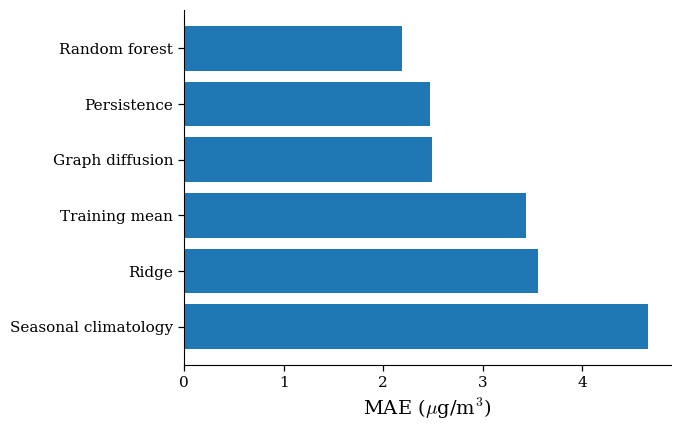

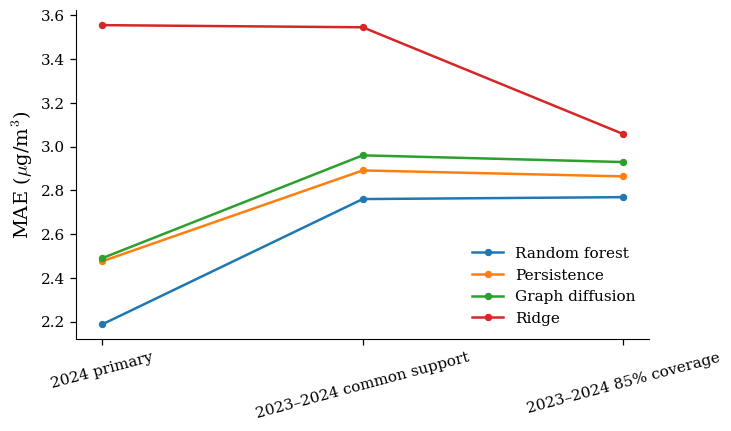

In [29]:
# Plot model performance
primary = modelresults[modelresults["protocol"].eq("test_full90_2024")].sort_values("mae")
fig,ax = plt.subplots(figsize=(7,4.5))
ax.barh(primary["model"],primary["mae"])
ax.invert_yaxis()
ax.set_xlabel(r"MAE ($\mu$g/m$^3$)")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(output/"model_mae_2024.png",dpi=300,bbox_inches="tight")
plt.show()
protocolorder = ["test_full90_2024","common90_2023_2024","full85_2023_2024"]
protocollabels = ["2024 primary","2023–2024 common support","2023–2024 85% coverage"]
modelorder = ["Random forest","Persistence","Graph diffusion","Ridge"]
plotdata = modelresults[
    modelresults["protocol"].isin(protocolorder)&modelresults["model"].isin(modelorder)
].pivot(index="protocol",columns="model",values="mae").reindex(protocolorder)
fig,ax = plt.subplots(figsize=(7.5,4.5))
for model in modelorder:
    ax.plot(protocollabels,plotdata[model],marker="o",label=model)
ax.set_ylabel(r"MAE ($\mu$g/m$^3$)")
ax.set_xlabel("")
ax.tick_params(axis="x",rotation=15)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(output/"model_robustness.png",dpi=300,bbox_inches="tight")
plt.show()


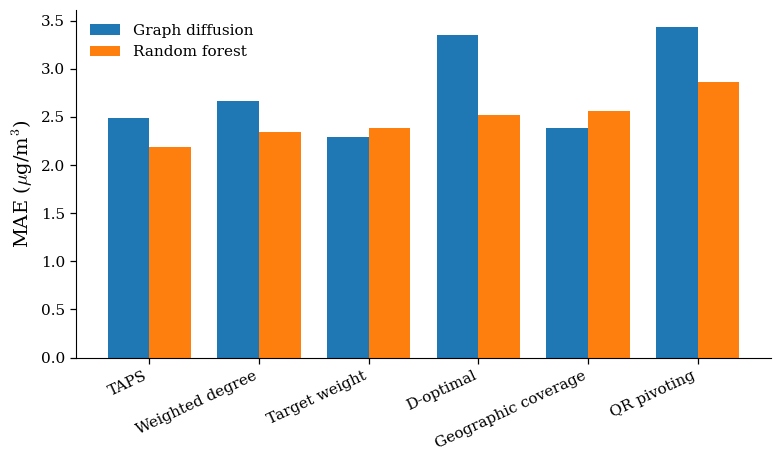

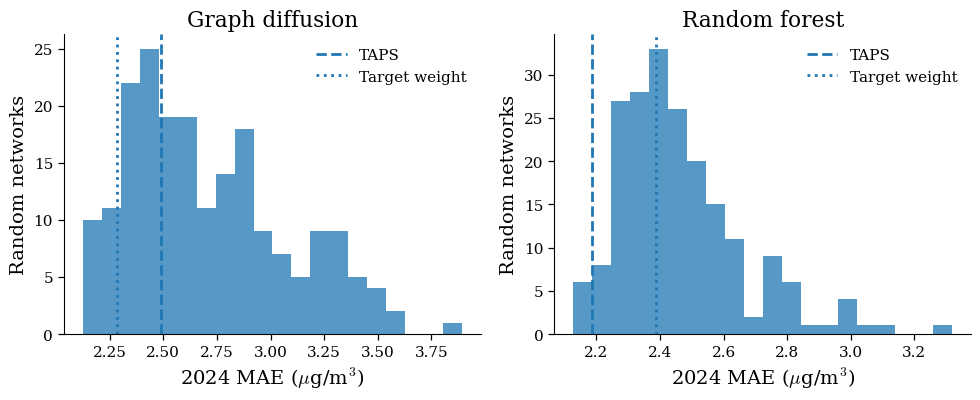

In [30]:
# Plot placement performance
primaryplacement = placementresults[placementresults["protocol"].eq("full90_2024")].pivot(index="placement",columns="predictor",values="mae")
primaryplacement = primaryplacement.sort_values("Random forest")
x = np.arange(len(primaryplacement))
width = .38
fig,ax = plt.subplots(figsize=(8,4.8))
ax.bar(x-width/2,primaryplacement["Graph diffusion"],width,label="Graph diffusion")
ax.bar(x+width/2,primaryplacement["Random forest"],width,label="Random forest")
ax.set_xticks(x)
ax.set_xticklabels(primaryplacement.index,rotation=25,ha="right")
ax.set_ylabel(r"MAE ($\mu$g/m$^3$)")
ax.set_xlabel("")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(output/"placement_comparison.png",dpi=300,bbox_inches="tight")
plt.show()
fig,axes = plt.subplots(1,2,figsize=(10,4.2))
linestyles = {"TAPS":"--","Target weight":":"}
for ax,predictor in zip(axes,["Graph diffusion","Random forest"]):
    randommae = randomplacementresults.loc[randomplacementresults["predictor"].eq(predictor),"mae"]
    ax.hist(randommae,bins=20,alpha=.75)
    deterministic = placementresults[
        placementresults["protocol"].eq("full90_2024")
        & placementresults["predictor"].eq(predictor)
        & placementresults["placement"].isin(linestyles)
    ]
    for row in deterministic.itertuples():
        ax.axvline(row.mae,linestyle=linestyles[row.placement],linewidth=2,label=row.placement)
    ax.set_title(predictor)
    ax.set_xlabel(r"2024 MAE ($\mu$g/m$^3$)")
    ax.set_ylabel("Random networks")
    ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(output/"random_placement.png",dpi=300,bbox_inches="tight")
plt.show()


In [31]:
# Export validation archive
tables = {
    "sample_summary.csv":samplesummary,
    "station_audit.csv":stationaudit,
    "target_agreement.csv":targetagreement,
    "target_protocols.csv":targetprotocols,
    "protocol_summary.csv":protocolsummary,
    "graph_summary.csv":graphsummary,
    "graph_checks.csv":graphchecks,
    "tuning_results.csv":tuning,
    "model_parameters.csv":modelparameters,
    "model_results.csv":modelresults,
    "model_winners.csv":modelwinners,
    "model_inventory.csv":modelinventory,
    "validation_results.csv":validationresults,
    "primary_test_results.csv":testresults,
    "robustness_results.csv":robusttable,
    "year_results.csv":yearresults,
    "model_bootstrap.csv":bootstrapresults,
    "regime_results.csv":regimeresults,
    "placement_results.csv":placementresults,
    "placement_bootstrap.csv":placementbootstrap,
    "placement_summary.csv":placementsummary,
    "random_placement_results.csv":randomplacementresults,
    "random_summary.csv":randomsummary,
    "random_percentiles.csv":randompercentiles,
    "random_correlations.csv":randomcorrelations,
    "sensor_sets.csv":sensorsets,
    "random_sets.csv":randomsettable,
    "validation_predictions.csv":validationpredictions,
    "primary_test_predictions.csv":testpredictions,
    "common_support_predictions.csv":commonpredictions,
    "sensitivity_predictions.csv":sensitivitypredictions,
    "placement_predictions.csv":primaryplacementpredictions
}
for name,table in tables.items():
    table.to_csv(output/name,index=False)
with open(output/"hyperparameters.json","w") as file:
    json.dump(parameters,file,indent=2)
manifest = {
    "notebook":"05-validation.ipynb",
    "input":"regions.zip from 01-regions.ipynb",
    "purpose":"Held-out PM2.5 prediction and sensor-placement validation",
    "primary_target":"Twenty-one-site population-weighted Bay Area target with ninety percent coverage",
    "primary_test":"2024",
    "robustness_target":"Seventeen-site fixed common support",
    "robustness_test":"2023-2024",
    "same_information_models":["Training mean","Seasonal climatology","Persistence","Ridge","Random forest","Graph diffusion"],
    "placement_methods":list(placementsets),
    "random_trials":len(randomsets),
    "external_models":"Qualitative comparison only",
    "figure_titles":False
}
with open(output/"manifest.json","w") as file:
    json.dump(manifest,file,indent=2)
required = [
    "model_results.csv","model_inventory.csv","primary_test_results.csv","placement_results.csv",
    "random_placement_results.csv","hyperparameters.json","manifest.json","model_mae_2024.png",
    "model_robustness.png","placement_comparison.png","random_placement.png"
]
missing = [name for name in required if not (output/name).exists()]
if missing:
    raise FileNotFoundError("Missing exports: "+", ".join(missing))
archive = Path("validation.zip")
if archive.exists():
    archive.unlink()
with zipfile.ZipFile(archive,"w",compression=zipfile.ZIP_DEFLATED) as bundle:
    for path in sorted(output.iterdir()):
        bundle.write(path,arcname=path.name)
print("Exported files:",len(list(output.iterdir())))
print("Archive:",archive)


Exported files: 38
Archive: validation.zip


In [32]:
# Download validation archive
files.download(str(archive))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>